# **IMPORTS**

In [1]:
from math import log2
import pandas as pd
import matplotlib.pyplot as plt

# **PREPARE DATASET**

In [2]:
columns = ['f1', 'f2', 'f3', 'f4', 'Y']

data = [
    [0, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [1, 1, 1, 0, 0],
    [1, 0, 0, 0, 0],
    [1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0],
    [1, 0, 0, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 1, 0, 0],
    [1, 0, 1, 0, 0],
    [1, 1, 0, 0, 0],
    [1, 1, 0, 1, 1],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1]
]

df = pd.DataFrame(data, columns=columns)

In [3]:
df

,f1,f2,f3,f4,Y
0,0,1,1,1,1
1,1,1,1,1,1
2,0,0,1,1,0
3,1,1,1,0,0
4,1,0,0,0,0
5,1,0,1,1,0
6,0,0,0,0,0
7,1,0,0,1,0
8,0,0,1,0,0
9,0,1,1,0,0


# **BUILD DECISION TREE**

## Function 1:  Entropy calculation

In [4]:
def entropy(labels):
    """Compute entropy of label distribution"""
    p1 = sum(labels) / len(labels)

    if p1 == 0 or p1 == 1:
        return 0

    p0 = 1 - p1

    return -(p1 * log2(p1) + p0 * log2(p0))

## Function 2: Information Gain calculation

In [5]:
def information_gain(df, feature):

    total_entropy = entropy(df['Y'])

    weighted_entropy = 0

    for value in df[feature].unique():

        subset = df[df[feature] == value]

        subset_entropy = entropy(subset['Y'])

        weighted_entropy += (len(subset) / len(df)) * subset_entropy

    return total_entropy - weighted_entropy

## Function 3: Build decision tree recursively

In [6]:
def build_tree(df, features, depth=0):

    indent = "    " * depth

    node_entropy = entropy(df['Y'])

    print(f"\n{indent}Node depth {depth}")
    print(f"{indent}Samples: {len(df)}")
    print(f"{indent}Entropy: {node_entropy:.4f}")

    # If pure node → create leaf
    if df['Y'].nunique() == 1:

        label = int(df['Y'].iloc[0])
        print(f"{indent}Leaf node → Y = {label}")

        return label

    # If no features left → majority vote
    if not features:

        label = int(df['Y'].mode()[0])
        print(f"{indent}Leaf (majority) → Y = {label}")

        return label

    print(f"{indent}Information Gain:")

    best_feature = None
    best_gain = -1

    for f in features:

        gain = information_gain(df, f)

        print(f"{indent}  IG({f}) = {gain:.4f}")

        if gain > best_gain:
            best_gain = gain
            best_feature = f

    print(f"{indent}Selected feature → {best_feature}")

    tree = {best_feature: {}}

    remaining = [f for f in features if f != best_feature]

    for value in sorted(df[best_feature].unique()):

        print(f"{indent}Split: {best_feature} = {int(value)}")

        subset = df[df[best_feature] == value]

        tree[best_feature][int(value)] = build_tree(subset, remaining, depth + 1)

    return tree

##  Function 4: print tree structure

In [7]:
def print_tree(tree, indent=""):

    if not isinstance(tree, dict):
        print(indent + "→ Y =", tree)
        return

    feature = list(tree.keys())[0]

    for value, subtree in tree[feature].items():

        print(f"{indent}if {feature} == {value}:")
        print_tree(subtree, indent + "    ")

## Get the result

In [8]:
# Start process

print("\n========== DATASET ENTROPY ==========")
dataset_entropy = entropy(df['Y'])
print(f"Entropy(D) = {dataset_entropy:.4f}")

print("\n========== BUILDING DECISION TREE ==========")

features = ['f1', 'f2', 'f3', 'f4']

tree = build_tree(df, features)

print("\n========== FINAL DECISION TREE ==========")

print_tree(tree)


========== DATASET ENTROPY ==========
Entropy(D) = 0.8113

========== BUILDING DECISION TREE ==========

Node depth 0
Samples: 16
Entropy: 0.8113
Information Gain:
  IG(f1) = 0.0000
  IG(f2) = 0.3113
  IG(f3) = 0.0000
  IG(f4) = 0.3113
Selected feature → f2
Split: f2 = 0

    Node depth 1
    Samples: 8
    Entropy: 0.0000
    Leaf node → Y = 0
Split: f2 = 1

    Node depth 1
    Samples: 8
    Entropy: 1.0000
    Information Gain:
      IG(f1) = 0.0000
      IG(f3) = 0.0000
      IG(f4) = 1.0000
    Selected feature → f4
    Split: f4 = 0

        Node depth 2
        Samples: 4
        Entropy: 0.0000
        Leaf node → Y = 0
    Split: f4 = 1

        Node depth 2
        Samples: 4
        Entropy: 0.0000
        Leaf node → Y = 1

========== FINAL DECISION TREE ==========
if f2 == 0:
    → Y = 0
if f2 == 1:
    if f4 == 0:
        → Y = 0
    if f4 == 1:
        → Y = 1


# **PLOT DECIOSION TREE**

In [9]:
def plot_tree(tree):
    # Create a matplotlib figure and axis
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Turn off axis lines and ticks
    ax.axis("off")

    def draw_node(node, x, y, dx):
        # If the node is a leaf (not a dictionary)
        if not isinstance(node, dict):
            ax.text(
                x, y, f"Y = {node}",
                ha="center", va="center",
                bbox=dict(boxstyle="round", facecolor="#bbf", edgecolor="black")
            )
            return
        
        # Extract the feature name (each node has a single key)
        feature = list(node.keys())[0]
        branches = node[feature]

        # Draw the feature node
        ax.text(
            x, y, feature,
            ha="center", va="center",
            bbox=dict(boxstyle="round", facecolor="#ffd", edgecolor="black")
        )

        # Determine horizontal spacing for child nodes
        child_count = len(branches)
        width = dx / child_count
        start_x = x - dx / 2 + width / 2

        # Iterate over each branch of the feature
        for i, (val, subtree) in enumerate(sorted(branches.items())):
            child_x = start_x + i * width
            child_y = y - 1.5

            # Draw the line connecting parent to child
            ax.plot([x, child_x], [y - 0.1, child_y + 0.1], color="black")

            # Label the edge with the feature value
            ax.text(
                (x + child_x) / 2,
                (y + child_y) / 2 + 0.1,
                str(val),
                ha="center",
                va="center"
            )

            # Recursively draw the subtree
            draw_node(subtree, child_x, child_y, dx / 2)

    # Start drawing from the root node
    draw_node(tree, x=0, y=0, dx=8)

    # Display the plot
    plt.savefig("tree_plot.png", dpi=300, bbox_inches="tight")
    plt.show()


Node depth 0
Samples: 16
Entropy: 0.8113
Information Gain:
  IG(f1) = 0.0000
  IG(f2) = 0.3113
  IG(f3) = 0.0000
  IG(f4) = 0.3113
Selected feature → f2
Split: f2 = 0

    Node depth 1
    Samples: 8
    Entropy: 0.0000
    Leaf node → Y = 0
Split: f2 = 1

    Node depth 1
    Samples: 8
    Entropy: 1.0000
    Information Gain:
      IG(f1) = 0.0000
      IG(f3) = 0.0000
      IG(f4) = 1.0000
    Selected feature → f4
    Split: f4 = 0

        Node depth 2
        Samples: 4
        Entropy: 0.0000
        Leaf node → Y = 0
    Split: f4 = 1

        Node depth 2
        Samples: 4
        Entropy: 0.0000
        Leaf node → Y = 1


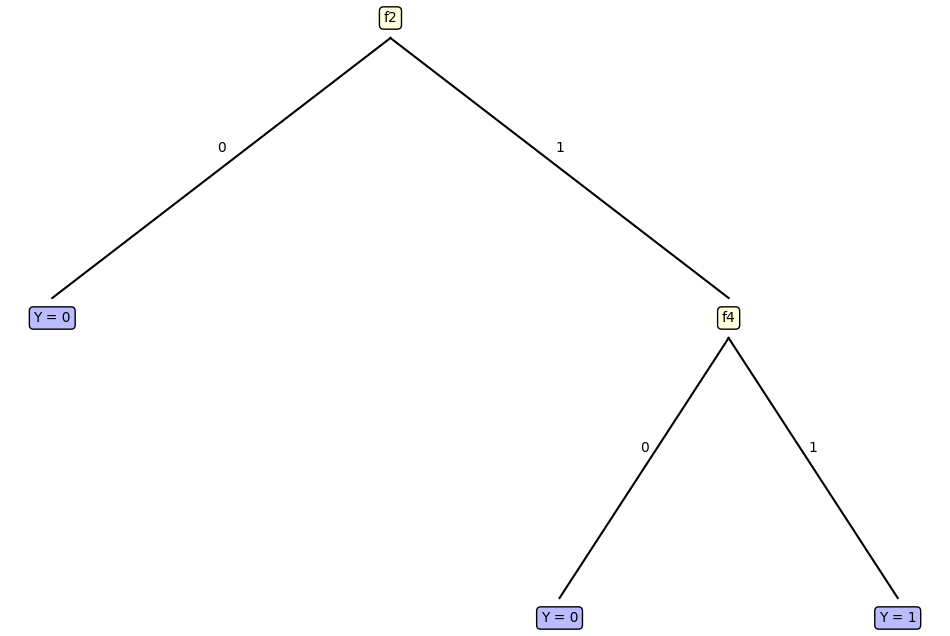

In [10]:
tree = build_tree(df, features)
plot_tree(tree)